In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv('/content/drive/MyDrive/Data Science/Dataset/bank.csv')

#Eda & Preprocessing

In [3]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


Displays the first five rows of the dataset to understand its structure, features, and sample records.

In [4]:
df.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,unknown,9,may,153,1,-1,0,unknown,no
4518,57,technician,married,secondary,no,295,no,no,cellular,19,aug,151,11,-1,0,unknown,no
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,feb,129,4,211,3,other,no
4520,44,entrepreneur,single,tertiary,no,1136,yes,yes,cellular,3,apr,345,2,249,7,other,no


Displays the last five rows to verify the dataset's ending records and overall consistency.

In [5]:
df.shape

(4521, 17)

Shows the total number of rows and columns in the dataset.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


Provides information about data types, non-null values, and memory usage for each feature.

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,4521.0,41.170095,10.576211,19.0,33.0,39.0,49.0,87.0
balance,4521.0,1422.657819,3009.638142,-3313.0,69.0,444.0,1480.0,71188.0
day,4521.0,15.915284,8.247667,1.0,9.0,16.0,21.0,31.0
duration,4521.0,263.961292,259.856633,4.0,104.0,185.0,329.0,3025.0
campaign,4521.0,2.793630,3.109807,1.0,1.0,2.0,3.0,50.0
pdays,4521.0,39.766645,100.121124,-1.0,-1.0,-1.0,-1.0,871.0
previous,4521.0,0.542579,1.693562,0.0,0.0,0.0,0.0,25.0


Generates descriptive statistics for numerical features, including mean, standard deviation, and quartiles.

In [8]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


Checks for missing values in each feature to determine if data cleaning is required.

In [9]:
df.duplicated().sum()

np.int64(0)

Identifies the number of duplicate records present in the dataset.

In [10]:
df.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64


Displays the data type of each feature to identify numerical and categorical variables.

In [11]:
df.nunique()

,0
age,67
job,12
marital,3
education,4
default,2
balance,2353
housing,2
loan,2
contact,3
day,31


Shows the number of unique values in each feature, helping identify categorical and high-cardinality variables.

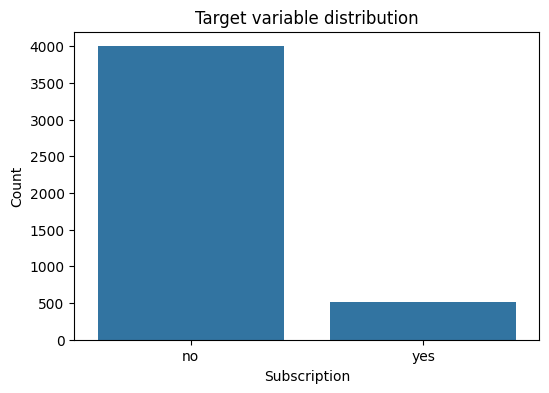

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(x='y',data=df)
plt.title("Target variable distribution")
plt.xlabel("Subscription")
plt.ylabel("Count")
plt.show()

Shows the distribution of the target variable and identifies class imbalance.

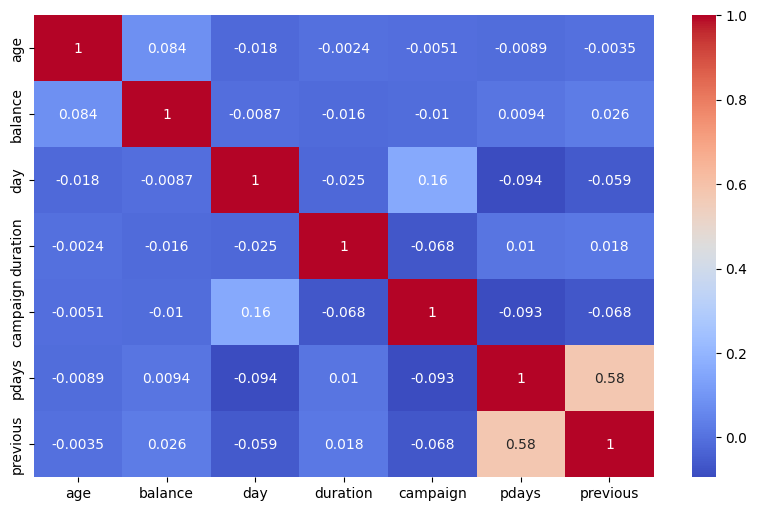

In [13]:
numeric_df=df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(),annot=True,cmap='coolwarm')
plt.show()

Shows the correlation between numerical features to identify linear relationships.

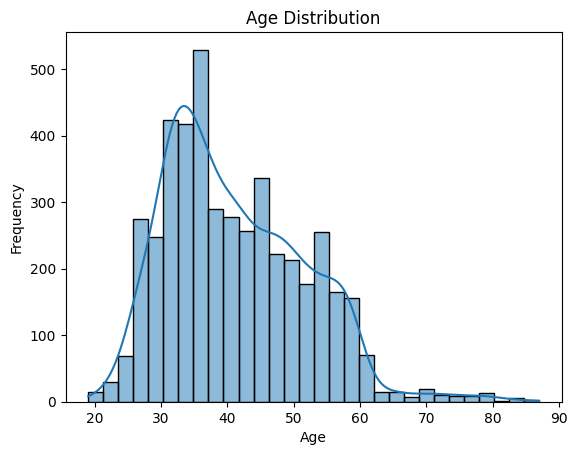

In [14]:
sns.histplot(df['age'],bins=30,kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

Shows the distribution of the age feature across all customers.

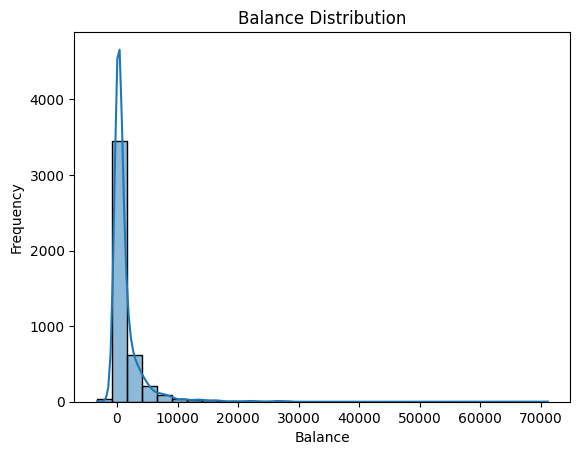

In [15]:
sns.histplot(df['balance'],bins=30,kde=True)

plt.title("Balance Distribution")
plt.xlabel("Balance")
plt.ylabel("Frequency")
plt.show()

Shows the distribution of customers' account balances.

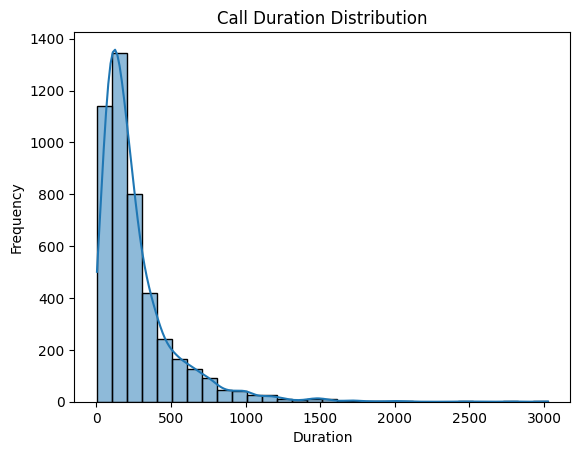

In [16]:
sns.histplot(df['duration'],bins=30,kde=True)

plt.title('Call Duration Distribution')
plt.xlabel('Duration')
plt.ylabel('Frequency')
plt.show()

Shows the distribution of call durations.

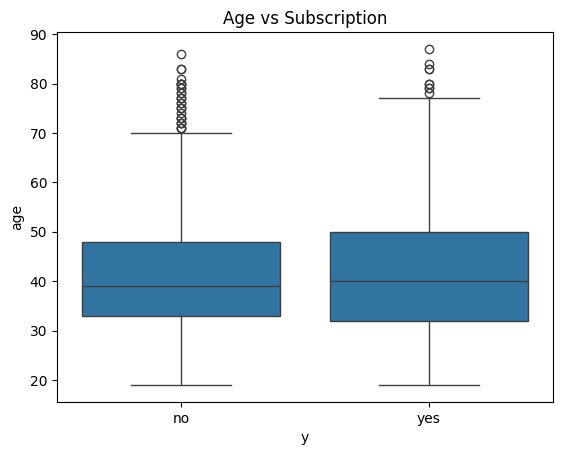

In [17]:
sns.boxplot(x=df['y'],y=df['age'])

plt.title("Age vs Subscription")
plt.show()

Subscribers tend to be slightly older than non-subscribers.

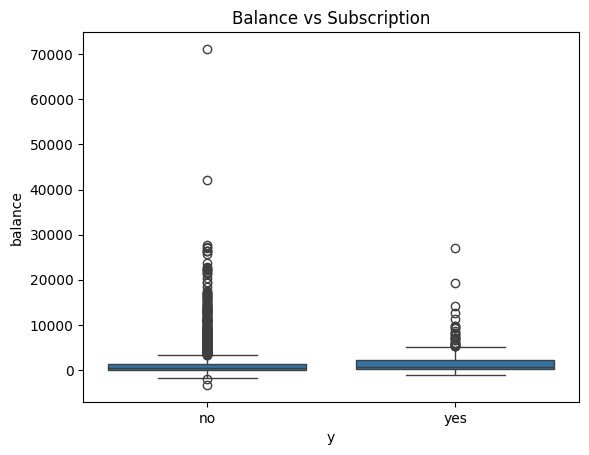

In [18]:
sns.boxplot(x=df['y'],y=df['balance'])

plt.title("Balance vs Subscription")
plt.show()

Subscribers generally have higher account balances than non-subscribers.

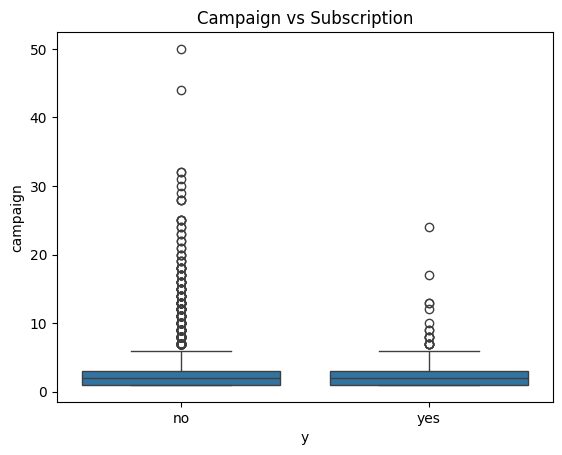

In [19]:
sns.boxplot(x=df['y'],y=df['campaign'])

plt.title('Campaign vs Subscription')

plt.show()

Subscribers generally required fewer campaign contacts than non-subscribers.

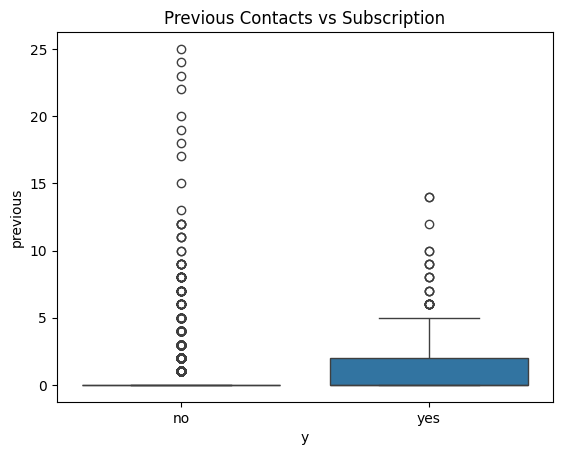

In [20]:
sns.boxplot(x=df['y'],y=df['previous'])

plt.title('Previous Contacts vs Subscription')

plt.show()

Subscribers generally had more previous contacts than non-subscribers.

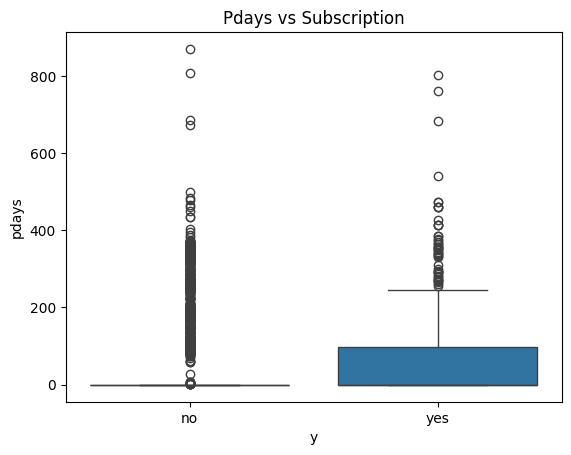

In [21]:
sns.boxplot(x=df['y'],y=df['pdays'])

plt.title('Pdays vs Subscription')

plt.show()

Most customers had not been contacted previously, resulting in a highly skewed distribution.

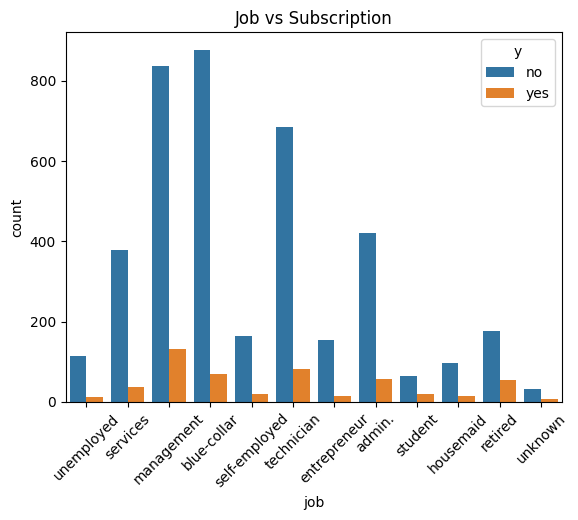

In [22]:
sns.countplot(x=df['job'],hue=df['y'])

plt.title("Job vs Subscription")
plt.xticks(rotation=45)
plt.show()

Subscription rates vary across different job categories.

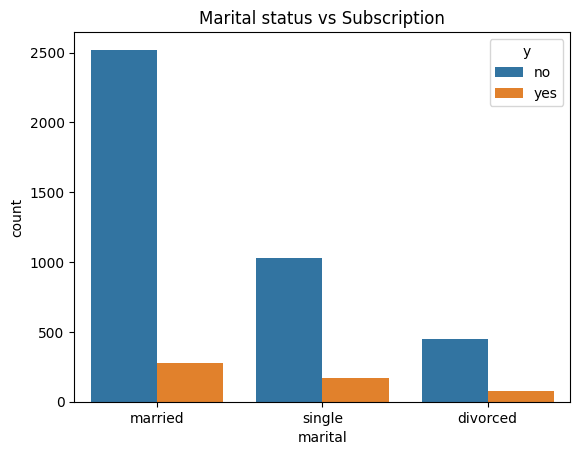

In [23]:
sns.countplot(x=df['marital'],hue=df['y'])

plt.title("Marital status vs Subscription")
plt.show()

Single customers generally have a higher subscription rate than married customers.

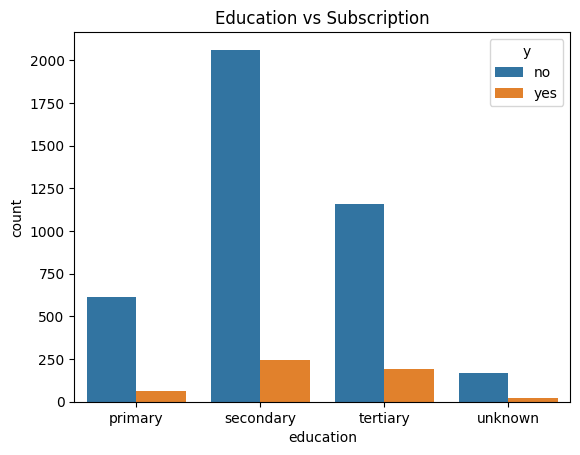

In [24]:
sns.countplot(x=df['education'],hue=df['y'])

plt.title("Education vs Subscription")
plt.show()

Subscription rates vary across different education levels.

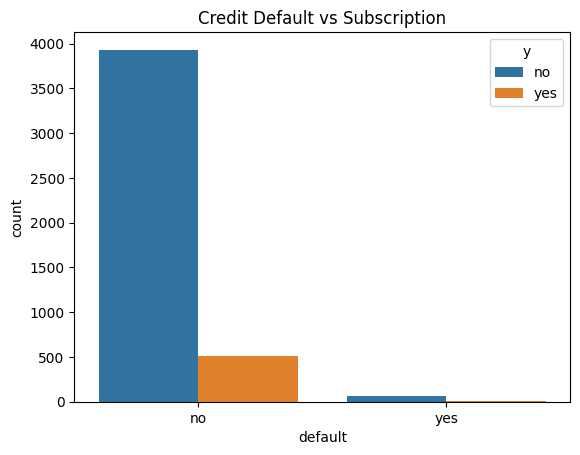

In [25]:
sns.countplot(x=df['default'],hue=df['y'])

plt.title("Credit Default vs Subscription")
plt.show()

Customers without a credit default are more likely to subscribe.

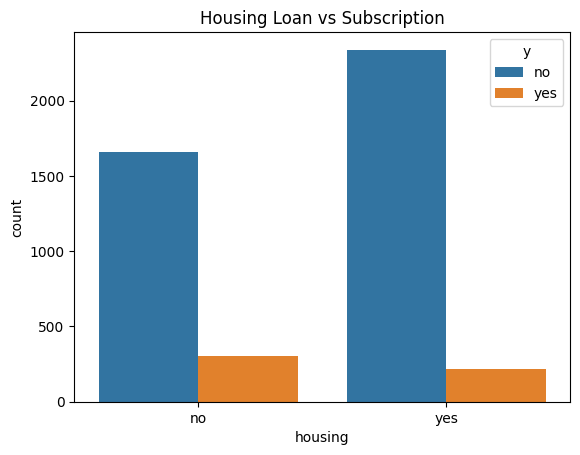

In [26]:
sns.countplot(x=df['housing'],hue=df['y'])

plt.title('Housing Loan vs Subscription')

plt.show()

Customers without a housing loan are more likely to subscribe.

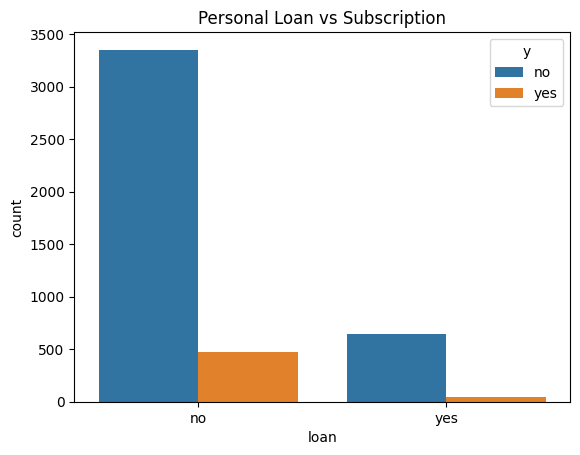

In [27]:
sns.countplot(x=df['loan'],hue=df['y'])

plt.title('Personal Loan vs Subscription')

plt.show()

Customers without a personal loan are more likely to subscribe.

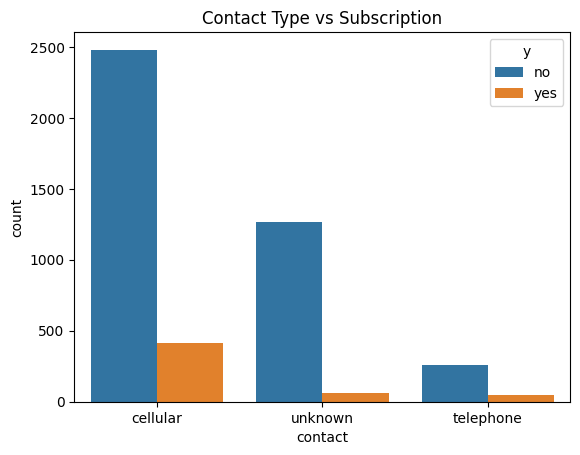

In [28]:
sns.countplot(x=df['contact'],hue=df['y'])

plt.title('Contact Type vs Subscription')

plt.show()

Cellular contact is associated with higher subscription rates than telephone contact.

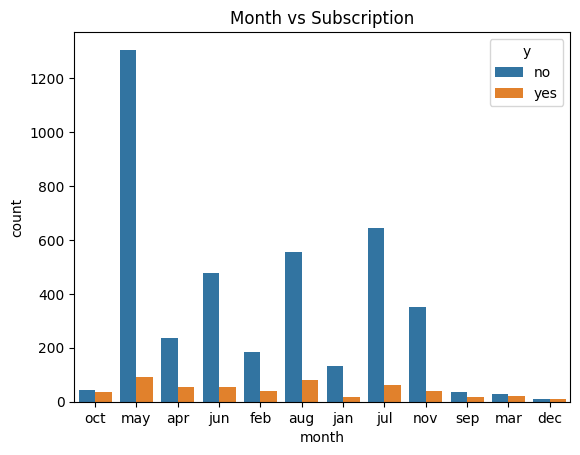

In [29]:
sns.countplot(x=df['month'],hue=df['y'])

plt.title('Month vs Subscription')

plt.show()

Subscription rates vary across different months.

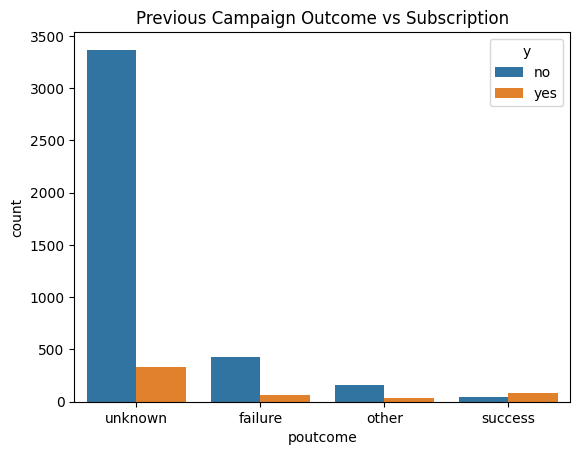

In [30]:
sns.countplot(x=df['poutcome'],hue=df['y'])

plt.title('Previous Campaign Outcome vs Subscription')

plt.show()

Customers with a successful previous campaign are more likely to subscribe.

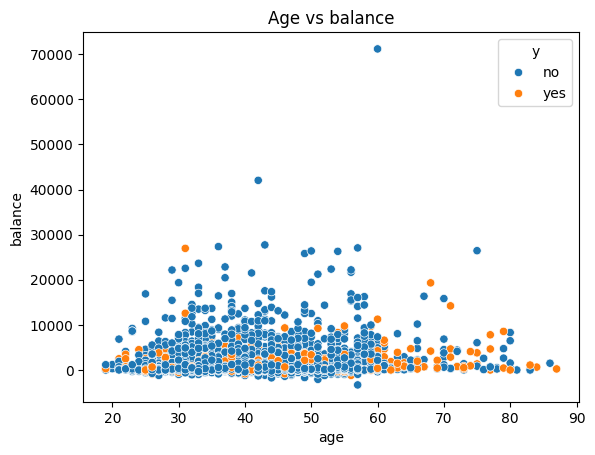

In [31]:
sns.scatterplot(x=df['age'],y=df['balance'],hue=df['y'])

plt.title("Age vs balance")
plt.show()

Shows the relationship between customer age, account balance, and subscription outcome.

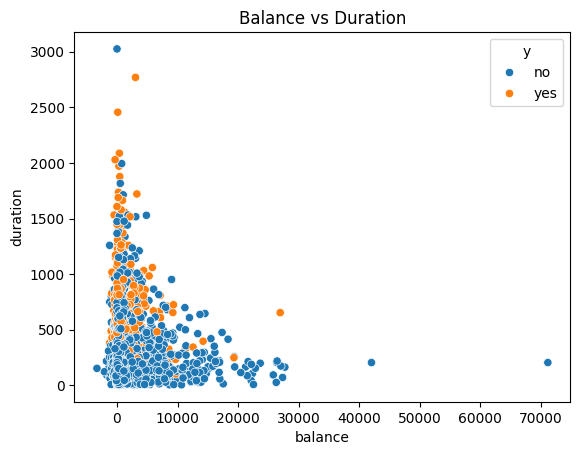

In [32]:
sns.scatterplot(x=df['balance'],y=df['duration'],hue=df['y'])

plt.title("Balance vs Duration")
plt.show()

Subscribers are more frequently associated with longer call durations.

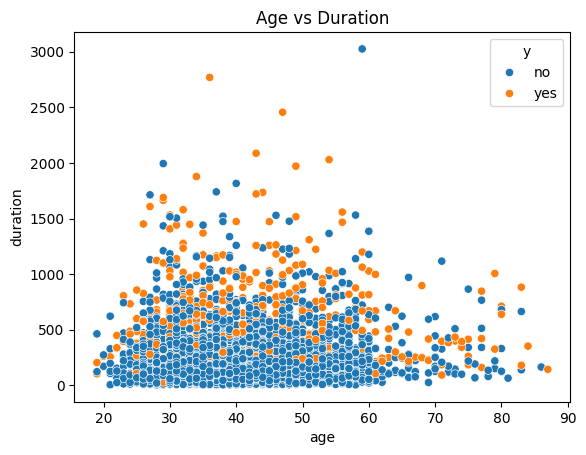

In [33]:
sns.scatterplot(x=df['age'],y=df['duration'],hue=df['y'])

plt.title("Age vs Duration")
plt.show()

Longer call durations are more frequently associated with subscribers.

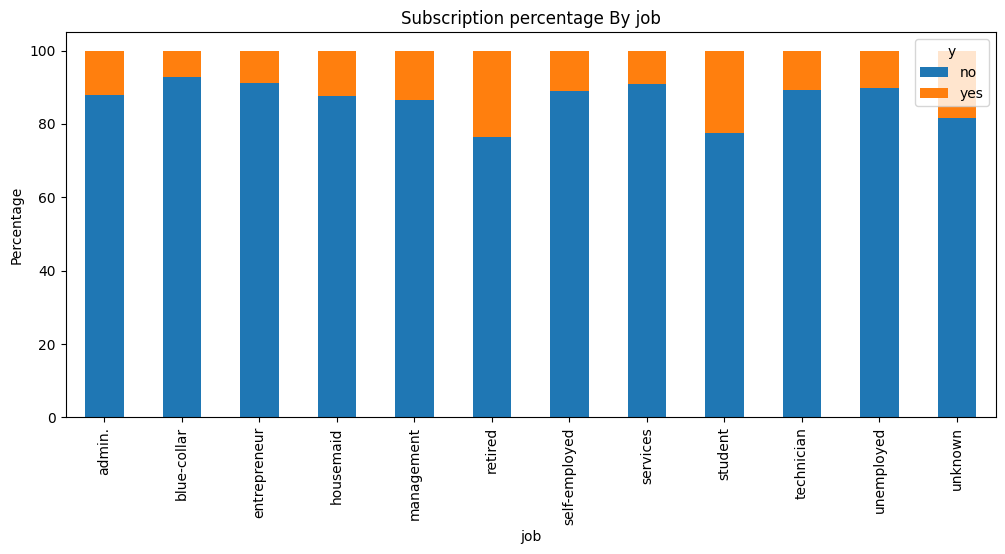

In [34]:
job_subscription=pd.crosstab(df['job'],df['y'],normalize='index')*100

job_subscription.plot(kind='bar',stacked=True,figsize=(12,5))

plt.title("Subscription percentage By job")
plt.ylabel("Percentage")
plt.show()

Students and retired customers have the highest subscription percentages.

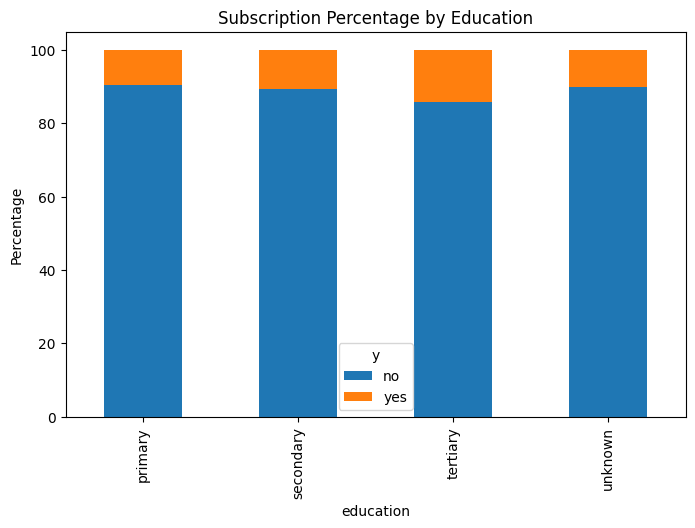

In [35]:
education_subscription = pd.crosstab(df['education'],
                                     df['y'],
                                     normalize='index') * 100

education_subscription.plot(kind='bar',
                            stacked=True,
                            figsize=(8,5))

plt.title('Subscription Percentage by Education')
plt.ylabel('Percentage')

plt.show()

Customers with tertiary education generally have the highest subscription percentage.

In [36]:
df['y'].value_counts()

,count
y,
no,4000
yes,521


The data are very imbalanced.

In [37]:
df.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64


In [38]:
#Separates the features and target variable.
X=df.drop('y',axis=1)
y=df['y']

In [39]:
#Encode Target Variable
y = y.map({'no':0,'yes':1})

In [40]:
numerical_features=X.select_dtypes(include=['int64','float64']).columns
categorical_features=X.select_dtypes(include=['object']).columns

In [41]:
#Converts categorical features into numerical dummy variables using One-Hot Encoding.
X=pd.get_dummies(X,columns=categorical_features,drop_first=True,dtype=int)

In [42]:
X.head()

,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,30,1787,19,79,1,-1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
1,33,4789,11,220,1,339,4,0,0,0,...,0,0,0,1,0,0,0,0,0,0
2,35,1350,16,185,1,330,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,30,1476,3,199,4,-1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
4,59,0,5,226,1,-1,0,1,0,0,...,0,0,0,1,0,0,0,0,0,1


In [43]:
#Splits the dataset into training and testing sets while preserving the class distribution.
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [44]:
#Standardizes numerical features to have a mean of 0 and a standard deviation of 1.

from sklearn.preprocessing import StandardScaler
ss=StandardScaler()

X_train[numerical_features]=ss.fit_transform(X_train[numerical_features])
X_test[numerical_features]=ss.transform(X_test[numerical_features])

#Logistic regression


In [45]:
from sklearn.linear_model import LogisticRegression

In [46]:
lr=LogisticRegression()

In [47]:
lr.fit(X_train,y_train)

LogisticRegression()

In [48]:
lr.coef_

array([[-0.05807019,  0.03994887,  0.05616516,  1.10698516, -0.21168421,
        -0.0141598 , -0.03137198, -0.44276218, -0.14995663, -0.50637872,
         0.04794539,  0.5194642 , -0.32955426, -0.22266404,  0.50757773,
        -0.28280461, -0.6487567 ,  0.29111233, -0.46245629, -0.27520034,
         0.16318609,  0.19613977, -0.45962297,  0.52020519, -0.37064204,
        -0.66891384, -0.06495197, -1.18006855, -0.23597167, -0.04449125,
         0.10343648, -0.8891235 , -0.51409449,  0.45486045,  1.40198139,
        -0.4979607 , -0.73196868,  1.60638914,  0.51655798,  0.42810151,
         2.18909747, -0.30521428]])

In [49]:
lr.intercept_

array([-1.32440619])

In [50]:
y_pred=lr.predict(X_test)

In [51]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

In [52]:
confusion_matrix(y_test,y_pred)

array([[777,  24],
       [ 73,  31]])

In [53]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94       801
           1       0.56      0.30      0.39       104

    accuracy                           0.89       905
   macro avg       0.74      0.63      0.67       905
weighted avg       0.87      0.89      0.88       905



In [54]:
accuracy_score(y_test,y_pred)*100

89.2817679558011

# Random Forest

In [55]:
from sklearn.ensemble import RandomForestClassifier

In [56]:
rf=RandomForestClassifier()

In [57]:
from sklearn.model_selection import GridSearchCV

In [58]:
para={'n_estimators':[50,100,120],'bootstrap':[True,False],'max_depth':[3,5,7,9]}

In [59]:
gsc=GridSearchCV(estimator=rf,param_grid=para,scoring='accuracy')

In [60]:
gsc.fit(X_train,y_train)

GridSearchCV(estimator=RandomForestClassifier(),
             param_grid={'bootstrap': [True, False], 'max_depth': [3, 5, 7, 9],
                         'n_estimators': [50, 100, 120]},
             scoring='accuracy')

In [61]:
gsc.best_params_

{'bootstrap': False, 'max_depth': 9, 'n_estimators': 50}

In [62]:
y_pred=gsc.best_estimator_.predict(X_test)

In [63]:
confusion_matrix(y_test,y_pred)

array([[789,  12],
       [ 87,  17]])

In [64]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.90      0.99      0.94       801
           1       0.59      0.16      0.26       104

    accuracy                           0.89       905
   macro avg       0.74      0.57      0.60       905
weighted avg       0.86      0.89      0.86       905



In [65]:
accuracy_score(y_test,y_pred)*100

89.06077348066297

#SMOTE

In [66]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_os, y_train_os = smote.fit_resample(
    X_train,
    y_train
)

In [67]:
print("Before SMOTE")
print(y_train.value_counts())

print("\nAfter SMOTE")
print(y_train_os.value_counts())

Before SMOTE
y
0    3199
1     417
Name: count, dtype: int64

After SMOTE
y
0    3199
1    3199
Name: count, dtype: int64


# LR after Over-Sampling

In [68]:
lr.fit(X_train_os,y_train_os)

LogisticRegression()

In [69]:
y_pred=lr.predict(X_test)

In [70]:
confusion_matrix(y_test,y_pred)

array([[713,  88],
       [ 45,  59]])

In [71]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.94      0.89      0.91       801
           1       0.40      0.57      0.47       104

    accuracy                           0.85       905
   macro avg       0.67      0.73      0.69       905
weighted avg       0.88      0.85      0.86       905



In [72]:
accuracy_score(y_test,y_pred)*100

85.30386740331491

# RF after Over-Sampling

In [73]:
gsc.fit(X_train_os,y_train_os)

GridSearchCV(estimator=RandomForestClassifier(),
             param_grid={'bootstrap': [True, False], 'max_depth': [3, 5, 7, 9],
                         'n_estimators': [50, 100, 120]},
             scoring='accuracy')

In [74]:
y_pred=gsc.best_estimator_.predict(X_test)

In [75]:
confusion_matrix(y_test,y_pred)

array([[715,  86],
       [ 40,  64]])

In [76]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.89      0.92       801
           1       0.43      0.62      0.50       104

    accuracy                           0.86       905
   macro avg       0.69      0.75      0.71       905
weighted avg       0.89      0.86      0.87       905



In [77]:
accuracy_score(y_test,y_pred)*100

86.07734806629834

#XGBoost After Over-Sampling

In [78]:
from xgboost.sklearn import XGBClassifier

In [79]:
xgb=XGBClassifier()

In [80]:
params={'n_estimators':[50,100,120],
        'max_depth':[3,5,7,9],
        'min_child_weight':[1,3,5,7],
        'learning_rate':[0.15,0.20,0.25,0.30]}

In [81]:
gsc=GridSearchCV(estimator=xgb,param_grid=params,scoring='accuracy')

In [82]:
gsc.fit(X_train_os,y_train_os)

GridSearchCV(estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=True, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     lear...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.15, 0.2, 0.25, 0.3],
                         'max_depth': [3, 5, 7, 9],
                         'min_child_weight': [1, 3, 5, 7],
                         'n_estimators': [50, 100, 120]},
             scoring='accuracy')

In [83]:
gsc.best_params_

{'learning_rate': 0.2,
 'max_depth': 9,
 'min_child_weight': 1,
 'n_estimators': 120}

In [84]:
y_pred=gsc.best_estimator_.predict(X_test)

In [85]:
confusion_matrix(y_test,y_pred)

array([[753,  48],
       [ 55,  49]])

In [86]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.93      0.94      0.94       801
           1       0.51      0.47      0.49       104

    accuracy                           0.89       905
   macro avg       0.72      0.71      0.71       905
weighted avg       0.88      0.89      0.88       905



In [87]:
accuracy_score(y_test,y_pred)*100

88.61878453038673

#Cross validation

In [88]:
from sklearn.model_selection import StratifiedKFold,cross_val_score

In [89]:
skf=StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    estimator=xgb,
    X=X_train_os,
    y=y_train_os,
    cv=skf,
    scoring='f1',
    n_jobs=-1
)

In [90]:
print("F1 Scores:", scores)
print("Mean F1:", scores.mean())
print("Std Dev:", scores.std())

F1 Scores: [0.94153846 0.93783576 0.94556765 0.94835681 0.95186335]
Mean F1: 0.9450324076685692
Std Dev: 0.004939621317427577


# Feature Importance

In [91]:
feature_importance=pd.DataFrame({
    'Feature':X_train.columns,
    'Importance':gsc.best_estimator_.feature_importances_
})

feature_importance=feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
27,contact_unknown,0.134084
32,month_jul,0.058925
3,duration,0.056989
25,loan_yes,0.055155
24,housing_yes,0.044950
36,month_nov,0.044759
35,month_may,0.041762
28,month_aug,0.036944
37,month_oct,0.035644
4,campaign,0.033984


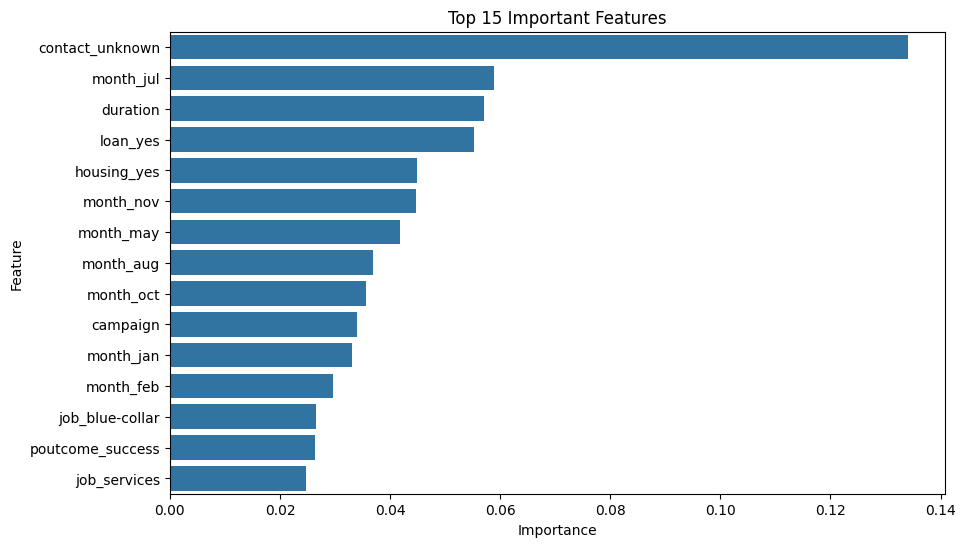

In [92]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")

plt.show()

In [94]:
#save final model

import joblib

# Final trained XGBoost model
xgb_final = gsc.best_estimator_

# Save the model
joblib.dump(xgb_final, "bank_marketing_xgb.pkl")

print("XGBoost model saved successfully!")

XGBoost model saved successfully!


#Conclusion

The project developed an end-to-end machine learning solution to predict customer subscription to bank term deposits. After preprocessing the data, encoding categorical features, scaling numerical variables, and handling class imbalance with SMOTE, multiple classification algorithms were evaluated. XGBoost achieved the best overall performance after hyperparameter tuning and cross-validation. The final model demonstrated strong predictive capability using F1-score and ROC-AUC, making it suitable for improving customer targeting in future marketing campaigns.